In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque
import random
import time

# ==================== 1. 电机模型（PMSM 离散仿真）====================

In [2]:

class PMSM:
	"""永磁同步电机离散模型（采用FOC常用d-q方程）"""
	def __init__(self, dt=1e-4):
		# 电机参数（典型小功率PMSM）
		self.Rs = 2.0          # 定子电阻 (Ohm)
		self.Ld = 8.5e-3       # d轴电感 (H)
		self.Lq = 8.5e-3       # q轴电感 (H，表贴式PMSM Ld = Lq)
		self.flux_pm = 0.175   # 永磁体磁链 (Wb)
		self.J = 1.5e-4        # 转动惯量 (kg·m²)
		self.B = 1e-5          # 阻尼系数 (N·m·s)
		self.P = 4              # 极对数
		self.dt = dt            # 仿真步长

		# 状态初始化
		self.id = 0.0           # d轴电流
		self.iq = 0.0           # q轴电流
		self.omega = 0.0        # 电角速度 (rad/s)
		self.theta = 0.0        # 转子电角度 (rad)
		self.Te = 0.0           # 电磁转矩

	def step(self, vd, vq, Tl):
		"""
		电机模型更新一步（采用一阶欧拉法）
		vd, vq: d-q轴电压 (V)
		Tl: 负载转矩 (N·m)
		返回: (id, iq, omega, theta)
		"""
		# 电流动态方程
		did_dt = (vd - self.Rs * self.id + self.omega * self.Lq * self.iq) / self.Ld
		diq_dt = (vq - self.Rs * self.iq - self.omega * (self.Ld * self.id + self.flux_pm)) / self.Lq

		# 转矩方程
		Te = 1.5 * self.P * (self.flux_pm * self.iq + (self.Ld - self.Lq) * self.id * self.iq)

		# 机械动态方程
		domega_dt = (Te - Tl - self.B * self.omega) / self.J

		# 积分更新（欧拉法）
		self.id += did_dt * self.dt
		self.iq += diq_dt * self.dt
		self.omega += domega_dt * self.dt
		self.theta += self.omega * self.dt

		# 电流限制（保护）
		self.id = np.clip(self.id, -5, 5)
		self.iq = np.clip(self.iq, -10, 10)

		self.Te = Te
		return np.array([self.id, self.iq, self.omega, self.theta])




# ==================== 2. 传统FOC电流环（保持PI控制）====================

In [3]:

class CurrentLoopPI:
	"""电流环PI控制器（内环），用于生成vd, vq"""
	def __init__(self, Kp=20, Ki=1000, dt=1e-4):
		self.Kp = Kp
		self.Ki = Ki
		self.dt = dt
		self.integral_d = 0
		self.integral_q = 0

	def compute(self, id_ref, iq_ref, id_meas, iq_meas):
		"""根据电流参考值和测量值计算vd, vq"""
		# d轴误差
		error_d = id_ref - id_meas
		self.integral_d += error_d * self.dt
		self.integral_d = np.clip(self.integral_d, -5000, 5000)  # 抗积分饱和

		# q轴误差
		error_q = iq_ref - iq_meas
		self.integral_q += error_q * self.dt
		self.integral_q = np.clip(self.integral_q, -5000, 5000)

		# PI输出 + 前馈解耦项（简化版）
		vd = self.Kp * error_d + self.Ki * self.integral_d
		vq = self.Kp * error_q + self.Ki * self.integral_q

		return vd, vq

	def reset(self):
		self.integral_d = 0
		self.integral_q = 0




# ================== 3. 强化学习智能体（TD3，替换速度环PI）==================

In [4]:

class Actor(nn.Module):
	"""策略网络：状态 -> 动作（iq_ref）"""
	def __init__(self, state_dim, action_dim, max_action):
		super().__init__()
		self.net = nn.Sequential(
			nn.Linear(state_dim, 128),
			nn.ReLU(),
			nn.Linear(128, 128),
			nn.ReLU(),
			nn.Linear(128, action_dim),
			nn.Tanh()  # 输出范围[-1,1]
		)
		self.max_action = max_action

	def forward(self, state):
		return self.net(state) * self.max_action

class Critic(nn.Module):
	"""价值网络：状态+动作 -> Q值"""
	def __init__(self, state_dim, action_dim):
		super().__init__()
		# Q1网络
		self.q1 = nn.Sequential(
			nn.Linear(state_dim + action_dim, 128),
			nn.ReLU(),
			nn.Linear(128, 128),
			nn.ReLU(),
			nn.Linear(128, 1)
		)
		# Q2网络（用于缓解高估）
		self.q2 = nn.Sequential(
			nn.Linear(state_dim + action_dim, 128),
			nn.ReLU(),
			nn.Linear(128, 128),
			nn.ReLU(),
			nn.Linear(128, 1)
		)

	def forward(self, state, action):
		sa = torch.cat([state, action], 1)
		return self.q1(sa), self.q2(sa)

class TD3Agent:
	"""TD3算法实现"""
	def __init__(self, state_dim, action_dim, max_action, lr=3e-4, gamma=0.99, tau=0.005):
		self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

		# GPU runtime hints
		if self.device.type == "cuda":
			torch.backends.cudnn.benchmark = True
			torch.backends.cuda.matmul.allow_tf32 = True
			try:
				torch.set_float32_matmul_precision("high")
			except Exception:
				pass

		self.actor = Actor(state_dim, action_dim, max_action).to(self.device)
		self.actor_target = Actor(state_dim, action_dim, max_action).to(self.device)
		self.actor_target.load_state_dict(self.actor.state_dict())

		self.critic = Critic(state_dim, action_dim).to(self.device)
		self.critic_target = Critic(state_dim, action_dim).to(self.device)
		self.critic_target.load_state_dict(self.critic.state_dict())

		# Faster optimizer path on CUDA if supported
		try:
			self.actor_optimizer = optim.AdamW(self.actor.parameters(), lr=lr, fused=(self.device.type == "cuda"))
		except TypeError:
			self.actor_optimizer = optim.AdamW(self.actor.parameters(), lr=lr)

		try:
			self.critic_optimizer = optim.AdamW(self.critic.parameters(), lr=lr, fused=(self.device.type == "cuda"))
		except TypeError:
			self.critic_optimizer = optim.AdamW(self.critic.parameters(), lr=lr)

		self.max_action = max_action
		self.gamma = gamma
		self.tau = tau
		self.total_it = 0

		self.use_amp = (self.device.type == "cuda")
		self.amp_dtype = torch.float16
		self.scaler = torch.amp.GradScaler("cuda", enabled=self.use_amp)

	def select_action(self, state, noise=0.1):
		"""选择动作（用于执行）"""
		with torch.inference_mode():
			state_t = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
			action = self.actor(state_t).squeeze(0).detach().cpu().numpy()

		if noise > 0:
			action = action + np.random.normal(0, noise * self.max_action, size=action.shape)
		return np.clip(action, -self.max_action, self.max_action)

	def train(self, replay_buffer, batch_size=256):
		"""训练一次"""
		self.total_it += 1
		state, action, reward, next_state, done = replay_buffer.sample(batch_size)

		# ----- Critic -----
		with torch.no_grad():
			with torch.autocast(device_type=self.device.type, dtype=self.amp_dtype, enabled=self.use_amp):
				noise = (torch.randn_like(action) * 0.2).clamp(-0.5, 0.5)
				next_action = (self.actor_target(next_state) + noise).clamp(-self.max_action, self.max_action)
				target_q1, target_q2 = self.critic_target(next_state, next_action)
				target_q = torch.min(target_q1, target_q2)
				target_value = reward + (1 - done) * self.gamma * target_q

		self.critic_optimizer.zero_grad(set_to_none=True)
		with torch.autocast(device_type=self.device.type, dtype=self.amp_dtype, enabled=self.use_amp):
			current_q1, current_q2 = self.critic(state, action)
			critic_loss = nn.functional.mse_loss(current_q1, target_value) + nn.functional.mse_loss(current_q2, target_value)

		self.scaler.scale(critic_loss).backward()
		self.scaler.step(self.critic_optimizer)

		# ----- Delayed Actor -----
		if self.total_it % 2 == 0:
			self.actor_optimizer.zero_grad(set_to_none=True)
			with torch.autocast(device_type=self.device.type, dtype=self.amp_dtype, enabled=self.use_amp):
				actor_action = self.actor(state)
				actor_sa = torch.cat([state, actor_action], 1)
				actor_loss = -self.critic.q1(actor_sa).mean()

			self.scaler.scale(actor_loss).backward()
			self.scaler.step(self.actor_optimizer)

			# 软更新目标网络
			for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
				target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

			for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
				target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

		self.scaler.update()



# ==================== 4. 经验回放池 ====================

In [5]:
class ReplayBuffer:
	def __init__(self, state_dim, action_dim, max_size=100_000):
		self.max_size = int(max_size)
		self.ptr = 0
		self.size = 0
		self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

		self.state = np.zeros((self.max_size, state_dim), dtype=np.float32)
		self.action = np.zeros((self.max_size, action_dim), dtype=np.float32)
		self.reward = np.zeros((self.max_size, 1), dtype=np.float32)
		self.next_state = np.zeros((self.max_size, state_dim), dtype=np.float32)
		self.done = np.zeros((self.max_size, 1), dtype=np.float32)

	def push(self, state, action, reward, next_state, done):
		i = self.ptr
		self.state[i] = state
		self.action[i] = action
		self.reward[i, 0] = reward
		self.next_state[i] = next_state
		self.done[i, 0] = float(done)

		self.ptr = (self.ptr + 1) % self.max_size
		self.size = min(self.size + 1, self.max_size)

	def sample(self, batch_size):
		idx = np.random.randint(0, self.size, size=batch_size)

		state = torch.from_numpy(self.state[idx]).to(self.device, non_blocking=True)
		action = torch.from_numpy(self.action[idx]).to(self.device, non_blocking=True)
		reward = torch.from_numpy(self.reward[idx]).to(self.device, non_blocking=True)
		next_state = torch.from_numpy(self.next_state[idx]).to(self.device, non_blocking=True)
		done = torch.from_numpy(self.done[idx]).to(self.device, non_blocking=True)
		return state, action, reward, next_state, done

	def __len__(self):
		return self.size



# ==================== 5. 训练环境封装 ====================

In [6]:
class MotorFOCEnv:
	"""FOC电机控制环境（强化学习接口）"""
	def __init__(self, dt=1e-4):
		self.motor = PMSM(dt)
		self.current_pi = CurrentLoopPI(dt=dt)
		self.dt = dt

		# 状态定义: [转速误差, 误差积分, 实际转速, iq] 4维
		self.state_dim = 4
		self.action_dim = 1  # iq_ref
		self.max_action = 10.0  # 最大q轴电流

		self.reset()

	def reset(self):
		"""重置环境"""
		self.motor = PMSM(self.dt)
		self.current_pi.reset()
		self.omega_ref      = 100.0  # 目标转速 rad/s (~955 rpm)
		self.t_load         = 0.0  # 负载转矩
		self.step_count     = 0
		self.error_integral = 0.0

		# 获取初始状态
		state = self._get_state()
		return state

	def _get_state(self):
		"""构建状态向量 (所有分量归一化到[-1, 1]，便于神经网络学习)"""
		error = self.omega_ref - self.motor.omega
		# 更新误差积分（简单累计）
		self.error_integral += error * self.dt
		self.error_integral = np.clip(self.error_integral, -100, 100)

		# 状态 = [归一化误差, 归一化误差积分, 归一化实际转速, 归一化iq]
		# error: [-200, 200] -> /200.0; error_integral: [-100, 100] -> /100.0; omega: [-200, 200] -> /200.0; iq: [-10, 10] -> /10.0
		state = np.array([
			error / 200.0,                # 归一化误差
			self.error_integral / 100.0,  # 归一化误差积分
			self.motor.omega / 200.0,     # 归一化实际转速
			self.motor.iq / 10.0          # 归一化iq
		], dtype=np.float32)
		return state

	def step(self, action):
		"""
		执行一步仿真
		action: iq_ref (q轴电流参考值)
		"""
		# 解析动作
		iq_ref = float(np.clip(action[0], -self.max_action, self.max_action))
		id_ref = 0.0  # id=0控制

		# 电流环PI计算vd, vq
		vd, vq = self.current_pi.compute(id_ref, iq_ref, self.motor.id, self.motor.iq)

		# 电机模型更新（假设负载转矩随时间变化，增加扰动）
		if self.step_count % 1000 == 500:
			self.t_load = 0.3  # 突然加载
		elif self.step_count % 1000 == 800:
			self.t_load = 0.0  # 突然卸载

		self.motor.step(vd, vq, self.t_load)

		# 计算奖励
		error = abs(self.omega_ref - self.motor.omega)
		# 奖励 = -误差 - 0.01*|iq|（惩罚大电流）
		reward = -error * 0.1 - 0.001 * abs(iq_ref - self.motor.iq)  # 奖励幅度加大

		# 判断是否结束（连续运行，一般无终止）
		done = False
		self.step_count += 1

		# 获取下一个状态
		next_state = self._get_state()

		return next_state, reward, done, {}

	def render(self):
		"""可视化（可选）"""
		pass




# ==================== 6. 训练主循环 ====================

In [7]:
def train_rl_foc(
	max_episodes=500,
	max_steps=2000,
	batch_size=256,
	start_steps=5000,
	train_freq=4,
	gradient_steps=4,
	log_interval=10
):
	env = MotorFOCEnv(dt=1e-4)
	agent = TD3Agent(env.state_dim, env.action_dim, env.max_action)
	replay_buffer = ReplayBuffer(state_dim=env.state_dim, action_dim=env.action_dim, max_size=1e5)

	total_env_steps = max_episodes * max_steps
	est_updates = max(0, (total_env_steps - start_steps) // train_freq) * gradient_steps
	print(f"[Train] device={agent.device}, total_env_steps={total_env_steps}, est_updates≈{est_updates}")

	episode_rewards = []
	global_t0 = time.perf_counter()
	env_step_count = 0
	update_count = 0

	for episode in range(max_episodes):
		ep_t0 = time.perf_counter()
		state = env.reset()
		episode_reward = 0.0

		for step in range(max_steps):
			if len(replay_buffer) < start_steps:
				action = np.random.uniform(-env.max_action, env.max_action, size=(env.action_dim,))
			else:
				action = agent.select_action(state, noise=0.1)

			next_state, reward, done, _ = env.step(action)
			replay_buffer.push(state, action, reward, next_state, done)

			if len(replay_buffer) >= start_steps and (step % train_freq == 0):
				for _ in range(gradient_steps):
					agent.train(replay_buffer, batch_size=batch_size)
					update_count += 1

			state = next_state
			episode_reward += reward
			env_step_count += 1
			if done:
				break

		episode_rewards.append(episode_reward)

		if (episode + 1) % log_interval == 0:
			elapsed = time.perf_counter() - global_t0
			ep_elapsed = time.perf_counter() - ep_t0
			steps_per_sec = env_step_count / max(elapsed, 1e-9)
			updates_per_sec = update_count / max(elapsed, 1e-9)
			avg_reward = np.mean(episode_rewards[-log_interval:])
			print(
				f"[Ep {episode+1:4d}/{max_episodes}] "
				f"avg_reward={avg_reward:9.2f} | "
				f"ep_time={ep_elapsed:6.2f}s | "
				f"steps/s={steps_per_sec:8.1f} | updates/s={updates_per_sec:7.1f} | "
				f"buffer={len(replay_buffer)}"
			)

	test_agent(env, agent)
	return agent

def test_agent(env, agent):
	"""测试训练好的智能体"""
	state          = env.reset()
	omega_history  = []
	iq_ref_history = []
	omega_ref      = env.omega_ref

	for _ in range(5000):  # 0.5秒 (dt=1e-4)
		action = agent.select_action(state, noise=0)  # 测试不加噪声
		next_state, _, _, _ = env.step(action)

		omega_history.append(env.motor.omega)
		iq_ref_history.append(action[0])

		state = next_state

	# 绘图
	plt.figure(figsize=(12, 5))

	plt.subplot(1, 2, 1)
	plt.plot(omega_history, label='Actual Speed')
	plt.axhline(y=omega_ref, color='r', linestyle='--', label='Reference')
	plt.xlabel('Time step')
	plt.ylabel('Speed (rad/s)')
	plt.legend()
	plt.title('Speed Tracking')

	plt.subplot(1, 2, 2)
	plt.plot(iq_ref_history)
	plt.xlabel('Time step')
	plt.ylabel('iq_ref (A)')
	plt.title('RL Agent Output (q-axis current reference)')

	plt.tight_layout()
	plt.show()




# ==================== 7. 运行训练 ====================

开始训练RL-FOC智能体...

测试未训练的智能体（随机控制）:


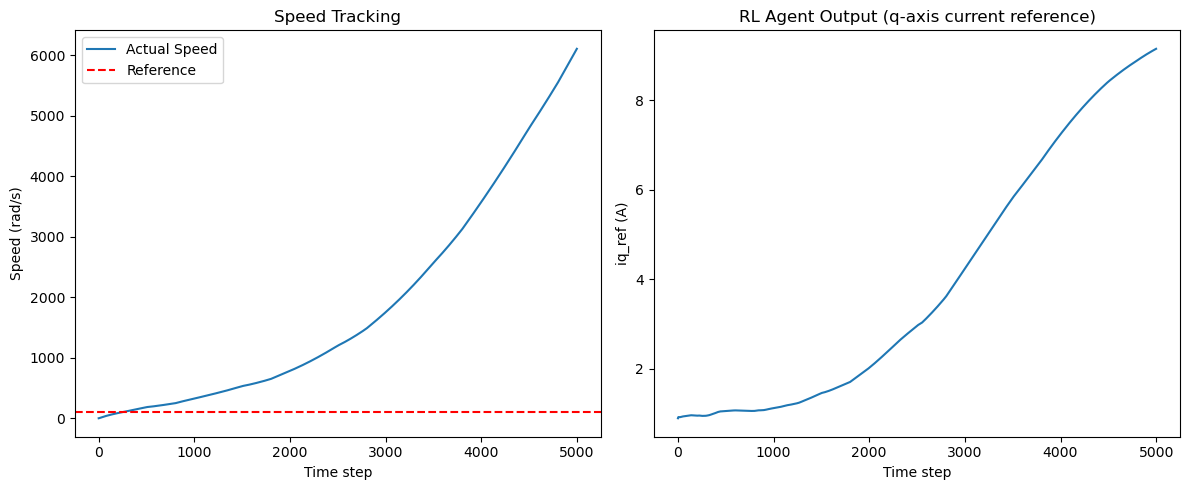


开始正式训练...
[Train] device=cuda, total_env_steps=1000000, est_updates≈995000
[Ep   10/500] avg_reward=-72002.77 | ep_time= 13.12s | steps/s=   197.7 | updates/s=  148.3 | buffer=20000
[Ep   20/500] avg_reward=  -934.15 | ep_time= 11.44s | steps/s=   180.5 | updates/s=  157.9 | buffer=40000
[Ep   30/500] avg_reward= -1007.90 | ep_time= 10.95s | steps/s=   178.8 | updates/s=  163.9 | buffer=60000
[Ep   40/500] avg_reward= -2831.65 | ep_time= 12.51s | steps/s=   179.1 | updates/s=  167.9 | buffer=80000
[Ep   50/500] avg_reward=  -667.08 | ep_time= 11.54s | steps/s=   178.3 | updates/s=  169.4 | buffer=100000
[Ep   60/500] avg_reward= -1652.86 | ep_time= 11.71s | steps/s=   177.0 | updates/s=  169.6 | buffer=100000
[Ep   70/500] avg_reward=  -312.09 | ep_time= 12.07s | steps/s=   175.9 | updates/s=  169.7 | buffer=100000
[Ep   80/500] avg_reward=  -446.21 | ep_time= 11.01s | steps/s=   175.1 | updates/s=  169.7 | buffer=100000
[Ep   90/500] avg_reward=  -314.89 | ep_time= 11.36s | steps/s= 

In [ ]:
if __name__ == "__main__":
	# 注意：完整训练可能需要数小时，这里只跑少量episode演示
	print("开始训练RL-FOC智能体...")
	# 为了演示，先初始化并测试一个未训练的agent
	env = MotorFOCEnv()
	agent = TD3Agent(env.state_dim, env.action_dim, env.max_action)

	print("\n测试未训练的智能体（随机控制）:")
	test_agent(env, agent)

	print("\n开始正式训练...")
	train_rl_foc(
		max_episodes=500,
		max_steps=2000,
		batch_size=256,
		start_steps=5000,
		train_freq=4,
		gradient_steps=4,
		log_interval=10
	)

	print("\n训练完成！")